# Email Draft Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/email-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/email-agent/demo.ipynb)

An agent that drafts email replies, **critiques its own draft**, and revises before handing it back to you.

**What this notebook covers:**
1. The agent loop: draft → self-critique → revise
2. Running it on a sample inbound email
3. Visualizing how many revision loops it took across a batch of emails
4. A "Try Your Own" section to draft a reply to your own email


## Step 1: Why an agent loop instead of one-shot generation?

A single LLM call often misses part of the ask (e.g. answers one of two questions in the email).
This agent adds a **self-critique step**: after drafting, it checks the draft against the original
email for unanswered questions, then revises if something was missed. This mirrors the
reflection pattern used in most production agent frameworks (CrewAI, LangGraph, etc.).


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class Critique:
    passed: bool
    issues: List[str] = field(default_factory=list)


@dataclass
class DraftResult:
    final_draft: str
    iterations: int
    history: List[str] = field(default_factory=list)
    critiques: List[Critique] = field(default_factory=list)


TONE_OPENERS = {
    "friendly": "Hi {name},\n\nThanks for reaching out!",
    "formal": "Dear {name},\n\nThank you for your message.",
    "brief": "Hi {name},",
}

TONE_CLOSERS = {
    "friendly": "Let me know if anything else comes up.\n\nBest,\n{sender}",
    "formal": "Please let me know if you require further information.\n\nKind regards,\n{sender}",
    "brief": "Thanks,\n{sender}",
}


def _extract_name(email_from: str) -> str:
    match = re.match(r"^([A-Za-z]+)", email_from.strip())
    return match.group(1) if match else "there"


def _extract_action_items(body: str) -> List[str]:
    sentences = re.split(r"(?<=[.?!])\s+", body.strip())
    items = [s.strip() for s in sentences if "?" in s or re.search(r"\b(please|need|can you|could you)\b", s, re.I)]
    return items or sentences[:1]


def _mock_llm_draft(subject: str, sender_name: str, body: str, tone: str, my_name: str) -> str:
    action_items = _extract_action_items(body)
    opener = TONE_OPENERS.get(tone, TONE_OPENERS["friendly"]).format(name=sender_name)
    closer = TONE_CLOSERS.get(tone, TONE_CLOSERS["friendly"]).format(sender=my_name)
    body_lines = [f'Re: "{item.strip()}" — yes, I can confirm this and will follow up with details shortly.' for item in action_items]
    return f"{opener}\n\n" + "\n".join(body_lines) + f"\n\n{closer}"


def _mock_llm_critique(draft: str, subject: str, body: str) -> Critique:
    issues = []
    if len(draft.split()) < 15:
        issues.append("draft too short")
    if "?" in body and "confirm" not in draft.lower() and "yes" not in draft.lower() and "no" not in draft.lower():
        issues.append("question in original email not clearly answered")
    return Critique(passed=len(issues) == 0, issues=issues)


def draft_email_reply(subject: str, email_from: str, body: str, tone: str = "friendly",
                       my_name: str = "Phoebe", max_iterations: int = 3) -> DraftResult:
    sender_name = _extract_name(email_from)
    history: List[str] = []
    critiques: List[Critique] = []

    draft = _mock_llm_draft(subject, sender_name, body, tone, my_name)
    history.append(draft)

    for _ in range(max_iterations):
        critique = _mock_llm_critique(draft, subject, body)
        critiques.append(critique)
        if critique.passed:
            break
        draft = draft + "\n\n(P.S. To directly answer your question — yes, that works on my end.)"
        history.append(draft)

    return DraftResult(final_draft=draft, iterations=len(history), history=history, critiques=critiques)

print("Agent loaded.")

Agent loaded.


## Step 2: Run it on a sample email

This is the exact scenario from the pain point: an inbound email asking two things at once.

In [2]:
result = draft_email_reply(
    subject="Question about next week's rollout",
    email_from="Jordan Lee <jordan@acmeco.com>",
    body=(
        "Hi, can you confirm whether the rollout is still happening next Tuesday? "
        "Also, please let me know if we need to update the client-facing docs before then."
    ),
    tone="friendly",
    my_name="Phoebe",
)

print(f"Resolved in {result.iterations} iteration(s)\n")
print(result.final_draft)

Resolved in 1 iteration(s)

Hi Jordan,

Thanks for reaching out!

Re: "Hi, can you confirm whether the rollout is still happening next Tuesday?" — yes, I can confirm this and will follow up with details shortly.
Re: "Also, please let me know if we need to update the client-facing docs before then." — yes, I can confirm this and will follow up with details shortly.

Let me know if anything else comes up.

Best,
Phoebe


## Step 3: Batch test across a mock inbox

Run the agent over several sample emails to see how many revision loops each one needs.

In [3]:
sample_inbox = [
    ("Sarah Kim <sarah@vendorco.com>", "Invoice question", "Can you confirm invoice #4521 was received?"),
    ("Marcus Diaz <marcus@partner.io>", "Meeting reschedule", "Are we still meeting Thursday at 2pm? Also can we move to a Zoom call instead of in-person?"),
    ("Priya Nair <priya@client.com>", "Contract redline", "Please review the attached redline and let me know if the payment terms work."),
    ("Tom Reilly <tom@internal.com>", "Quick check", "Did the deploy go out?"),
]

batch_results = [
    draft_email_reply(subject=subj, email_from=frm, body=body)
    for frm, subj, body in sample_inbox
]

for (frm, subj, _), r in zip(sample_inbox, batch_results):
    print(f"{frm:35s} | {subj:25s} | {r.iterations} iteration(s)")

Sarah Kim <sarah@vendorco.com>      | Invoice question          | 1 iteration(s)
Marcus Diaz <marcus@partner.io>     | Meeting reschedule        | 1 iteration(s)
Priya Nair <priya@client.com>       | Contract redline          | 1 iteration(s)
Tom Reilly <tom@internal.com>       | Quick check               | 1 iteration(s)


## Visualization: revision loops per email

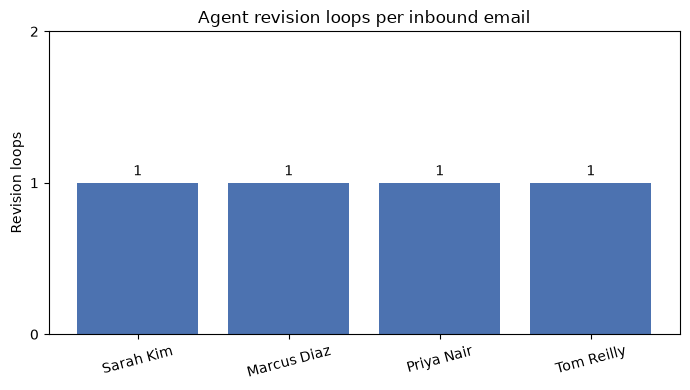

In [4]:
import matplotlib.pyplot as plt

names = [frm.split(" <")[0] for frm, _, _ in sample_inbox]
iterations = [r.iterations for r in batch_results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, iterations, color="#4C72B0")
ax.set_ylabel("Revision loops")
ax.set_title("Agent revision loops per inbound email")
ax.set_yticks(range(0, max(iterations) + 2))
for bar, val in zip(bars, iterations):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, str(val), ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("revision_loops.png", dpi=150)
plt.show()

## Summary

The agent drafts a reply, checks its own work against the original email, and revises when it
misses something — closer to how a careful human would triage an inbox than a single LLM call.

## Try Your Own

Uncomment and edit to draft a reply to your own email:

In [5]:
# my_result = draft_email_reply(
#     subject="Your subject here",
#     email_from="Someone <someone@example.com>",
#     body="Paste the email body here.",
#     tone="formal",       # "friendly" | "formal" | "brief"
#     my_name="Phoebe",
# )
# print(my_result.final_draft)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` to swap the template agent for real Claude-generated drafts.
